In [1]:
import pandas as  pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine('sqlite:///../sql/f1_analytics.db')

print("Connected!")

Connected!


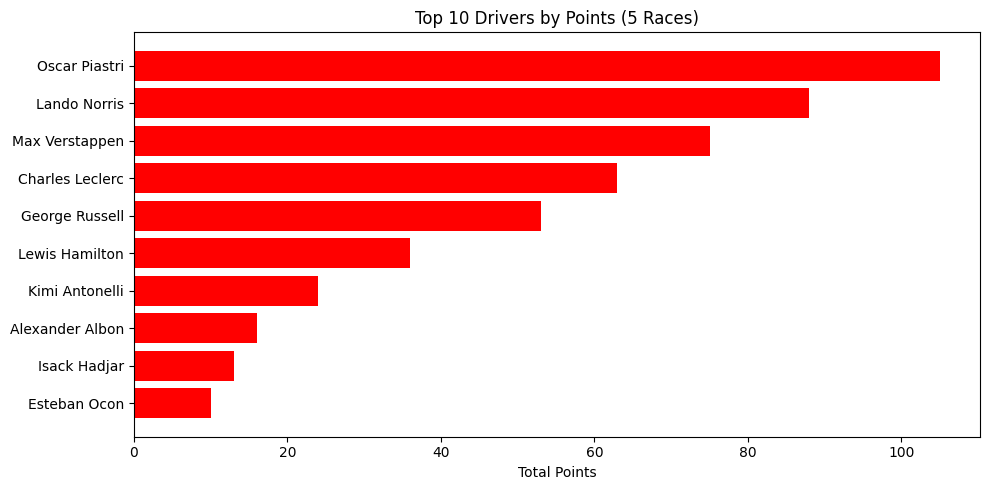

          FullName         TeamName  TotalPoints
0    Oscar Piastri          McLaren        105.0
1     Lando Norris          McLaren         88.0
2   Max Verstappen  Red Bull Racing         75.0
3  Charles Leclerc          Ferrari         63.0
4   George Russell         Mercedes         53.0
5   Lewis Hamilton          Ferrari         36.0
6   Kimi Antonelli         Mercedes         24.0
7  Alexander Albon         Williams         16.0
8     Isack Hadjar     Racing Bulls         13.0
9     Esteban Ocon     Haas F1 Team         10.0


In [15]:
# Q1: Who scored the most points across all 5 races?
query = """
SELECT FullName, TeamName, SUM(Points) as TotalPoints
FROM race_results
GROUP BY FullName, TeamName
ORDER BY TotalPoints DESC
LIMIT 10
"""
df = pd.read_sql(query, engine)

# Chart
plt.figure(figsize=(10,5))
plt.barh(df['FullName'], df['TotalPoints'], color='red')
plt.xlabel('Total Points')
plt.title('Top 10 Drivers by Points (5 Races)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/01_points_standings.png')
plt.show()

print(df)

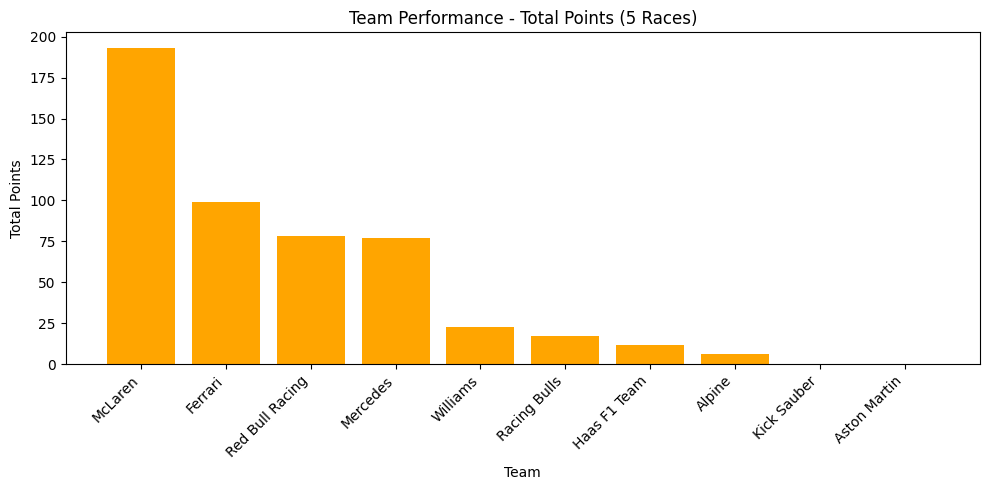

          TeamName  AvgFinishPosition  TotalPoints
0          McLaren                2.1        193.0
1          Ferrari                5.2         99.0
2  Red Bull Racing                8.4         78.0
3         Mercedes                7.3         77.0
4         Williams               10.4         23.0
5     Racing Bulls               11.8         17.0
6     Haas F1 Team               12.3         12.0
7           Alpine               15.2          6.0
8      Kick Sauber               16.8          0.0
9     Aston Martin               15.5          0.0


In [5]:
# Q2: Which team performed the best on average?
query = """
SELECT TeamName,
Round(AVG(Position), 2) as AvgFinishPosition
SUM(Points) as TotalPoints
FROM race_results
GROUP BY TeamName
ORDER BY TotalPoints DESC
"""
df = pd.read_sql(query, engine)

plt.figure(figsize=(10,5))
plt.bar(df['TeamName'], df['TotalPoints'], color='orange')
plt.xlabel('Team')
plt.ylabel('Total Points')
plt.title('Team Performance - Total Points (5 Races)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/02_team_performance.png')
plt.show()

print(df)

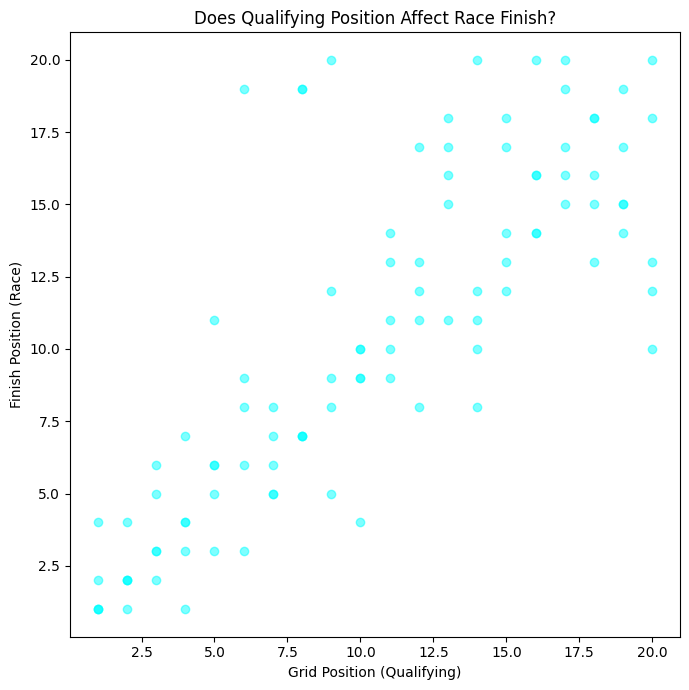

In [6]:
# Q3: Does starting position affect finish position?
query = """
SELECT FullName, GridPosition, Position
FROM race_results
WHERE GridPosition > 0
"""
df = pd.read_sql(query, engine)

plt.figure(figsize=(7,7))
plt.scatter(df['GridPosition'], df['Position'], alpha=0.5, color='cyan')
plt.xlabel('Grid Position (Qualifying)')
plt.ylabel('Finish Position (Race)')
plt.title('Does Qualifying Position Affect Race Finish?')
plt.tight_layout()
plt.savefig('../reports/03_grid_vs_finish.png')
plt.show()

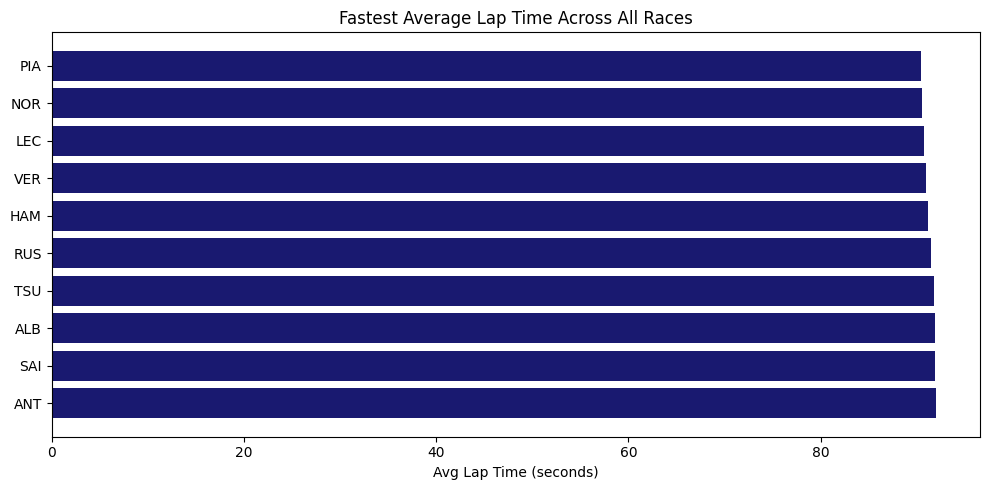

  Driver  AvgLapTime  TotalLaps
0    PIA      90.408        292
1    NOR      90.561        292
2    LEC      90.781        292
3    VER      90.976        293
4    HAM      91.169        292
5    RUS      91.501        290
6    TSU      91.731        243
7    ALB      91.843        290
8    SAI      91.894        278
9    ANT      91.963        289


In [16]:
# Q4: Which driver had the fastest average lap time?
query = """
SELECT Driver,
        ROUND(AVG(LapTime_sec), 3) as AvgLapTime,
        COUNT(*) as TotalLaps
from lap_details
WHERE LapTime_sec IS NOT NULL
AND LapTime_sec > 60
GROUP BY Driver
HAVING COUNT(*) > 200
ORDER BY AvgLapTime ASC
LIMIT 10
"""
df = pd.read_sql(query, engine)

plt.figure(figsize=(10,5))
plt.barh(df['Driver'], df['AvgLapTime'], color='midnightblue')
plt.xlabel('Avg Lap Time (seconds)')
plt.title('Fastest Average Lap Time Across All Races')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/04_fastest_avg_lap.png')
plt.show()

print(df)

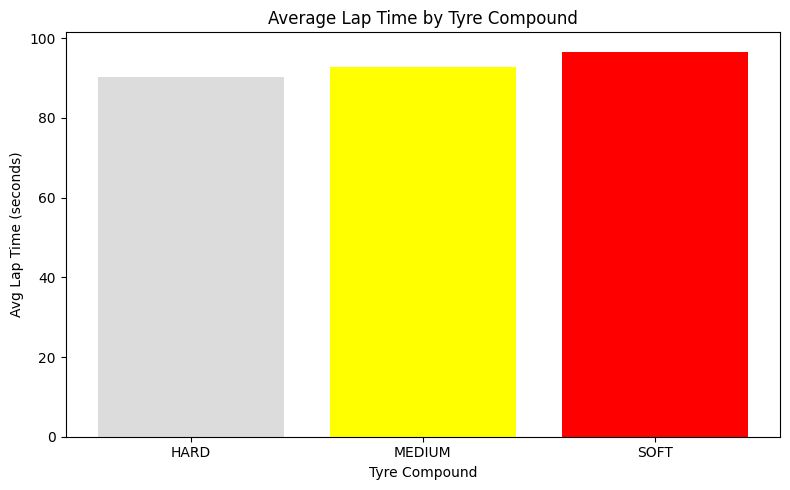

  Compound  AvgLapTime  LapCount
0     HARD      90.288      2668
1   MEDIUM      92.753      2026
2     SOFT      96.630       412


In [10]:
# Q5: How did tyre compound affect lap time?
query = """
SELECT Compound,
        ROUND(AVG(LapTime_sec), 3) as AvgLapTime,
        COUNT(*) as LapCount
FROM lap_details
WHERE LapTime_sec IS NOT NULL
AND LapTime_sec > 60
AND Compound IS NOT NULL
GROUP BY Compound
ORDER BY AvgLapTime ASC
"""
df = pd.read_sql(query, engine)

plt.figure(figsize=(8,5))
plt.bar(df['Compound'], df['AvgLapTime'], color=['gainsboro','yellow','red','green','blue'])
plt.xlabel('Tyre Compound')
plt.ylabel('Avg Lap Time (seconds)')
plt.title('Average Lap Time by Tyre Compound')
plt.tight_layout()
plt.savefig('../reports/05_tyre_compound.png')
plt.show()

print(df)

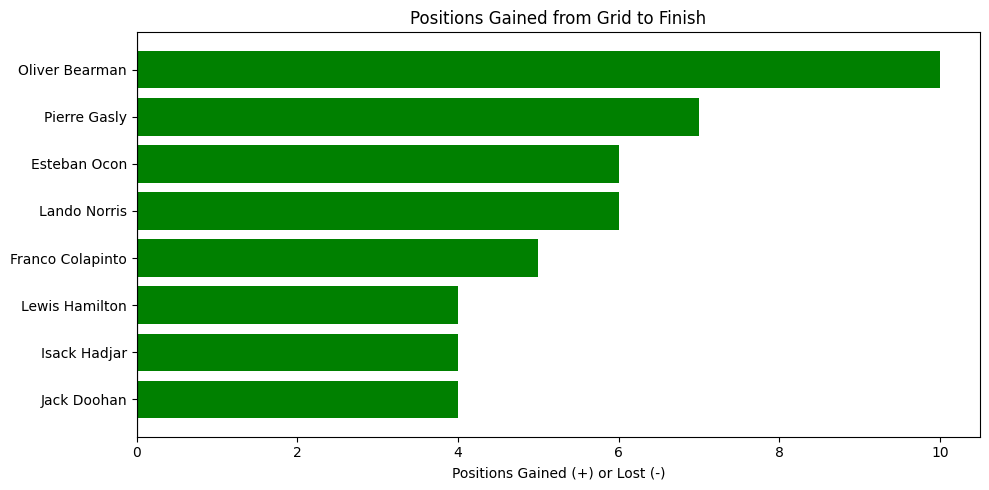

           FullName  GridPosition  Position  PositionsGained
0    Oliver Bearman          20.0      10.0             10.0
1    Oliver Bearman          20.0      12.0              8.0
2      Pierre Gasly          20.0      13.0              7.0
3      Esteban Ocon          14.0       8.0              6.0
4      Lando Norris          10.0       4.0              6.0
5      Esteban Ocon          19.0      14.0              5.0
6  Franco Colapinto          18.0      13.0              5.0
7    Lewis Hamilton           9.0       5.0              4.0
8      Isack Hadjar          14.0      10.0              4.0
9       Jack Doohan          19.0      15.0              4.0


In [14]:
# Q6: Which driver gaiined the most positions from grid to finish?
query = """
SELECT FullName,
        GridPosition,
        Position,
        (GridPosition - Position) as PositionsGained
FROM race_results
WHERE GridPosition > 0
ORDER BY PositionsGained DESC
LIMIT 10
"""
df = pd.read_sql(query, engine)

plt.figure(figsize=(10,5))
colors = ['green' if x >= 0 else 'red' for x in df['PositionsGained']]
plt.barh(df['FullName'], df['PositionsGained'], color=colors)
plt.xlabel('Positions Gained (+) or Lost (-)')
plt.title('Positions Gained from Grid to Finish')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/06_positions_gained.png')
plt.show()

print(df)

Chart 1:
McLaren dominate early 2025 with Piastri (105pts) ahead of Norris (88pts). Verstappen trails in 3rd at 75pts, suggesting Red Bull have lost their edge. Massive drop-off after P5 — top 5 drivers hold 76% of all points.

Chart 2:
McLaren are the standout team — averaging P2.1 finishes and nearly double Ferrari's points (193 vs 99). Red Bull (78pts) and Mercedes (77pts) are almost level despite Mercedes averaging better finishing positions, suggesting Red Bull score points more inconsistently. Kick Sauber and Aston Martin scored zero points across all 5 races

Chart 3:
Drivers starting in positions 1–5 frequently finish in the top 5, confirming qualifying matters. However the scatter widens significantly after grid position 8 — meaning midfield and backmarker results are far less predictable. A few outliers starting P15+ still finished in the top 10, showing overtaking is possible but uncommon at the front.

Chart 4:
Piastri leads all drivers with the fastest average lap time (90.4s) among drivers completing full races. Norris and Leclerc are within 0.4s, confirming McLaren and Ferrari are evenly matched on raw pace. Verstappen sits 0.6s behind Piastri despite Red Bull's strong points haul, suggesting race strategy plays a bigger role than outright speed for Red Bull.

Chart 5:
Hard tyres show the fastest average lap time (90.3s) across 2668 laps, while Softs appear slowest at 96.6s — counterintuitive but explained by degradation. Softs are fastest when new but drop off sharply, and their small sample (412 laps) is dominated by worn, late-stint laps. This highlights that tyre management and stint length matter more than compound alone.

# Note: Soft tyre average is misleading — small sample (412 laps) 
# dominated by degraded laps. Peak soft pace not captured here.

Chart 6:
Oliver Bearman is the standout overtaker — twice starting P20 and finishing P10 and P12, gaining 10 and 8 positions respectively. Norris and Hamilton appear in the top gainers despite driving competitive cars, suggesting strong race craft on top of machinery advantage. Notably most big movers start from P14 or lower, confirming that front runners rarely need to overtake.